In [1]:
import pandas as pd

In [3]:
data=pd.read_csv('cristina_.csv')

C:\Users\akshaya\AppData\Local\Temp\ipykernel_158908\2257867071.py:1: DtypeWarning: Columns (67,73,75,87,92,93,99,150,152,153,155,156,162,164,170,179,181,182,183,184,185,186,187,188,189,195,353,354) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv('cristina_.csv')


In [17]:
df=data[['imo','vessel','corrected_date','report_date_time','status','lat','long','latitude',
 'longitude','me_foc','cargo_total','total_steaming_time','me_fuel_only_steaming_time','miles_by_gps','speed_by_log',
 'speed_by_gps', 'rpm', 'slip', 'wind_direction', 'wind_speed', 'draft_aft', 'draft_fwd',"eta_port",'port_code','port','steaming_time_me_rsdl_vls',
 'steaming_time_me_rsdl_hs',"manvrng_miles_by_gps",
 'steaming_time_me_rsdl_uls',
 'steaming_time_me_dstlt_vls',
 'steaming_time_me_dstlt_uls',
 'steaming_time_me_tnktnr_dstlt_vls',
 'steaming_time_me_mdo',
 'steaming_time_aux_1',
 'steaming_time_aux_2',
 'steaming_time_aux_3',
 'steaming_time_aux_4',
 'steaming_time_aux_5',
 'steaming_time_sh_gen',
 'steaming_time_tg',
 'fuel_me_rsdl_vls',
 'fuel_me_rsdl_hs',
 'fuel_me_rsdl_uls',
 'fuel_me_dstlt_vls',
 'fuel_me_dstlt_uls',
 'fuel_me_mdo',
 'fuel_me_tnktnr_dstlt_vls',
 'fuel_aux_rsdl_vls',
 'fuel_aux_rsdl_hs',
 'fuel_aux_rsdl_uls',
 'fuel_aux_dstlt_vls',
 'fuel_aux_dstlt_uls',
 'fuel_aux_tnktnr_dstlt_vls',
 'fuel_aux_mdo',
 'fuel_boiler_rsdl_vls',
 'fuel_boiler_rsdl_hs',
 'fuel_boiler_rsdl_uls',
 'fuel_boiler_dstlt_vls',
 'fuel_boiler_dstlt_uls',
 'fuel_boiler_tnktnr_dstlt_vls',
 'fuel_boiler_mdo',
 'power_kw']]

In [19]:
df=data.copy()

In [21]:
df = df.sort_values(by='report_date_time')
df

,id,pi_sog,pi_stw,true_wind_dir,true_wind_speed,relative_wind_speed,relative_wind_direction,caa,corrected_power,rw,...,rob_garbage_cat_a_plastic,rob_garbage_cat_b_organic,rob_garbage_cat_c_domestic,rob_garbage_cat_e_ashes,qty_sludge_disposed,steaming_time_m_e_lng,reefer_power_consumption,wind_direction_side,sea_direction_side,tot_sludge_removed
4632,275628,NaN,NaN,160.84400,8.62705,4.42274,105.89300,0.141935,7313.86000,-11597.70000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4700,493573,NaN,NaN,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4873,318706,-100.00000,-100.00000,-50.00000,5.65884,4.93726,30.00000,0.580520,7832.00000,15454.36772,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4874,318775,-6.52722,-8.60439,-3.82233,1.33555,10.15363,4.41927,0.632010,23080.55432,16591.92682,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4697,318974,-2.54813,-4.76295,60.20392,11.41130,4.67257,73.86070,-0.107050,27937.39387,-68578.18149,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489,6444321,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,60S,118S,NaN
490,6444322,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
491,6444323,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,80S,137S,NaN
492,6444324,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,115S,151S,NaN


In [23]:
df_port = df[['port']].dropna().copy()

# Step 2: Create 'next_port' column by shifting the 'port' column
df_port['next_port'] = df_port['port'].shift(-1)

# Step 3: Drop rows where 'next_port' is NaN (in df_port, not df)
df_port = df_port.dropna(subset=['next_port'])

# Step 4: Filter out rows where 'port' is the same as 'next_port'
df_port = df_port[df_port['port'] != df_port['next_port']]

# Step 5: Group by 'port' and 'next_port', and count visits
visit_counts = df_port.groupby(['port', 'next_port']).size().reset_index(name='count')

# Step 6: Pivot the visit counts
pivot_count = visit_counts.pivot(index='port', columns='next_port', values='count').fillna(0)

# Step 7: Convert counts to integers
pivot_count = pivot_count.astype(int)

# Optionally reset the index for better readability
pivot_count = pivot_count.reset_index()

# Step 8: Add a total count column
pivot_count['total_count'] = pivot_count.iloc[:, 1:].sum(axis=1)

# Rename the index column to 'port' for clarity
pivot_count.rename(columns={'port': 'port'}, inplace=True)

# Display the resulting pivot table
print(pivot_count)


next_port           port  ABIDJAN  ABU DHABI  AD DAMMAM  ANTWERP  BARCELO  \
0                ABIDJAN        0          0          0        0        0   
1              ABU DHABI        0          0          0        0        0   
2              AD DAMMAM        0          2          0        0        0   
3                ANTWERP        0          0          0        0        0   
4                BARCELO        0          0          0        0        0   
..                   ...      ...        ...        ...      ...      ...   
76                XIAMEN        0          0          0        0        0   
77         YANGSHAN PORT        0          0          0        0        0   
78               YANTIAN        0          0          0        0        0   
79                 YEOSU        0          0          0        0        0   
80              ZHOUSHAN        0          0          0        0        0   

next_port  BARCELONA  BEIRUT  BREMERHAVEN  BUSAN  ...  UMM QASR PT  VALENCI

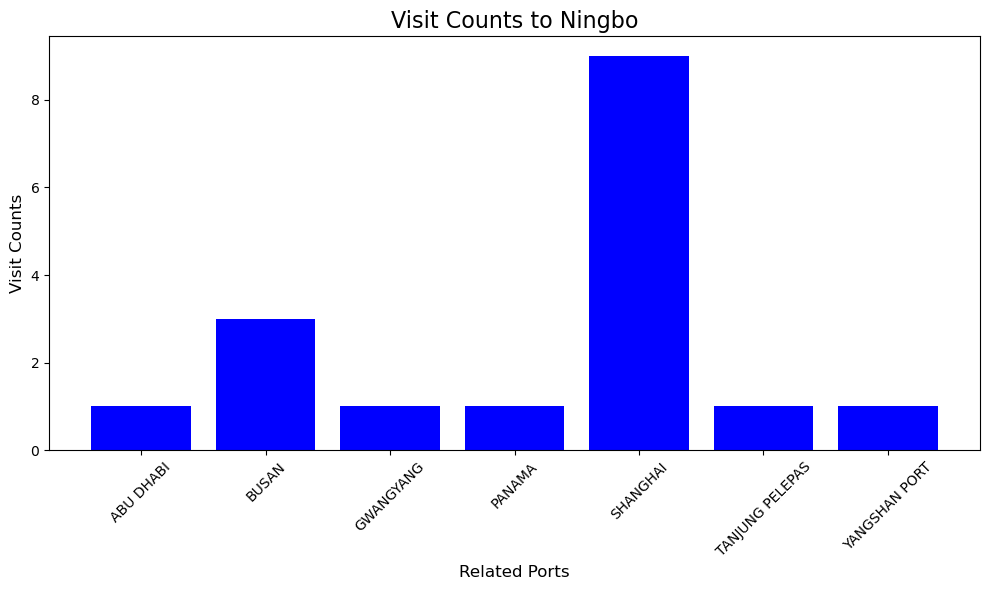

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming pivot_count is already created as in your previous steps

# Step 1: Define the target port (e.g., "Ningbo")
target_port = "NINGBO".upper()  # Normalize to uppercase for case-insensitivity

# Step 2: Check if the target port exists in the pivot_count DataFrame columns
if target_port in pivot_count.columns:
    # Step 3: Filter to get only the rows where the target port has non-zero visit counts
    related_ports_df = pivot_count[pivot_count[target_port] > 0][['port', target_port]].copy()
    
    if not related_ports_df.empty:  # Proceed only if there are relevant rows
        # Step 4: Plot the bar chart for only the related ports
        plt.figure(figsize=(10, 6))
        plt.bar(related_ports_df['port'], related_ports_df[target_port], color='blue')
        
        # Add labels and title
        plt.title(f'Visit Counts to {target_port.capitalize()}', fontsize=16)
        plt.xlabel('Related Ports', fontsize=12)
        plt.ylabel('Visit Counts', fontsize=12)
        plt.xticks(rotation=45)
        plt.tight_layout()  # Adjust layout to prevent clipping
        plt.show()
    else:
        print(f"No visit counts to display for {target_port}.")
else:
    print(f"{target_port} not found in the data.")


In [ ]:
# Step 1: Create a copy of the DataFrame to work on transitions
df_in_port = df[['port']].copy()

# Step 2: Remove consecutive duplicates (consecutive port visits should not be double counted)
df_in_port = df_in_port[df_in_port['port'] != df_in_port['port'].shift()]

# Step 3: Initialize a list to store the next valid port, skipping any gaps or NaN values
next_ports = []

# Step 4: Loop through the DataFrame to find the next valid port, skipping NaN values
for i in range(len(df_in_port)):
    current_port = df_in_port.iloc[i]['port']
    next_port = None
    
    # Look ahead to find the next valid port, skipping over gaps or NaNs
    for j in range(i + 1, len(df_in_port)):
        if pd.notna(df_in_port.iloc[j]['port']):
            next_port = df_in_port.iloc[j]['port']
            break
    
    # Append the next valid port, or None if no valid port is found
    next_ports.append(next_port)

# Step 5: Add the 'next_port' column to the DataFrame
df_in_port['next_port'] = next_ports

# Step 6: Drop rows where 'next_port' is NaN (to exclude incomplete transitions)
df_in_port = df_in_port.dropna(subset=['next_port'])

# Step 7: Calculate the counts of transitions between ports
visit_counts = df_in_port.groupby(['port', 'next_port']).size().reset_index(name='count')

# Step 8: Filter for transitions involving 'NINGBO' as either 'port' or 'next_port'
ningbo_data = visit_counts[(visit_counts['port'] == 'NINGBO') | (visit_counts['next_port'] == 'NINGBO')]

# Display the results
ningbo_data


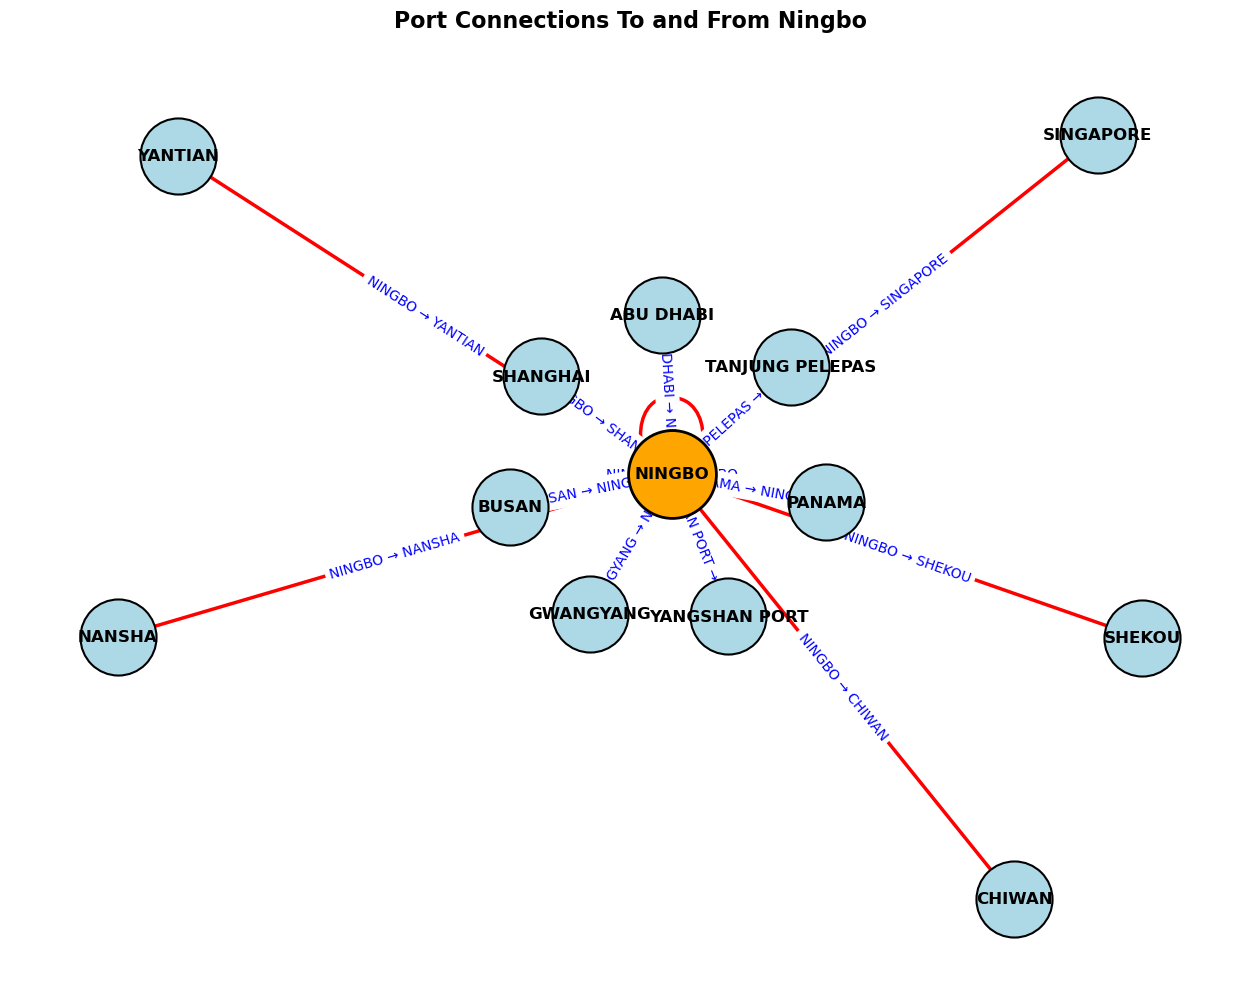

In [27]:
import matplotlib.pyplot as plt
import networkx as nx

# Step 1: Create a subset with the 'port' column
df_in_port = df[['port']].copy()

# Step 2: Create the 'next_port' column by shifting the 'port' column to get the next port in the sequence
df_in_port['next_port'] = df_in_port['port'].shift(-1)

# Step 3a: Filter rows where the next port is 'NINGBO' (i.e., arriving at Ningbo)
to_ningbo_travel = df_in_port[df_in_port['next_port'] == 'NINGBO']

# Step 3b: Filter rows where the current port is 'NINGBO' (i.e., departing from Ningbo)
from_ningbo_travel = df_in_port[df_in_port['port'] == 'NINGBO']

# Step 4: Drop rows with missing ports and duplicates
to_ningbo_travel = to_ningbo_travel.dropna(subset=['port'])
to_ningbo_travel = to_ningbo_travel.drop_duplicates(subset=['port', 'next_port'])

from_ningbo_travel = from_ningbo_travel.dropna(subset=['next_port'])
from_ningbo_travel = from_ningbo_travel.drop_duplicates(subset=['port', 'next_port'])

# Step 5: Create a directed graph to handle both directions (to and from Ningbo)
G = nx.DiGraph()

# Add edges for ports that travel to Ningbo
for _, row in to_ningbo_travel.iterrows():
    G.add_edge(row['port'], row['next_port'])

# Add edges for ports that depart from Ningbo
for _, row in from_ningbo_travel.iterrows():
    G.add_edge(row['port'], row['next_port'])

# Step 6: Draw the graph with enhancements
plt.figure(figsize=(16, 12))

# Use spring layout for a balanced, natural visual appearance
pos = nx.spring_layout(G, k=0.5)  # k controls the distance between nodes

# Draw the nodes
nx.draw_networkx_nodes(G, pos, 
                       node_color='lightblue', 
                       node_size=3000, 
                       edgecolors='black', 
                       linewidths=1.5)

# Highlight Ningbo node
nx.draw_networkx_nodes(G, pos, 
                       nodelist=['NINGBO'], 
                       node_color='orange', 
                       node_size=4000, 
                       edgecolors='black', 
                       linewidths=2)

# Draw the edges with colors and thickness
edge_colors = ['red' if 'NINGBO' in (u, v) else 'gray' for u, v in G.edges()]
edge_widths = [2.5 if 'NINGBO' in (u, v) else 1.5 for u, v in G.edges()]

nx.draw_networkx_edges(G, pos, 
                       arrowstyle='-|>', 
                       arrowsize=15, 
                       edge_color=edge_colors, 
                       width=edge_widths)

# Draw the labels with proper font size
nx.draw_networkx_labels(G, pos, 
                        font_size=12, 
                        font_color='black', 
                        font_weight='bold')

# Add edge labels (optional, to show route names)
edge_labels = {(u, v): f"{u} → {v}" for u, v in G.edges() if 'NINGBO' in (u, v)}
nx.draw_networkx_edge_labels(G, pos, 
                             edge_labels=edge_labels, 
                             font_color='blue', 
                             font_size=10)

# Set title and display the graph
plt.title('Port Connections To and From Ningbo', fontsize=16, fontweight='bold', pad=20)
plt.axis('off')  # Turn off the axis
plt.show()
